# Conditional Co-Recall by Category

> Compute and visualize conditional co-recall probability grouped by category relation.

Conditional co-recall by category measures how the probability that a neighbor was recalled depends on whether it belongs to the same or a different category as a recalled anchor item. For a given reference category (e.g., neutral items), each recalled anchor from that category contributes to two bins: same-category neighbors and different-category neighbors.

A higher same-category probability relative to different-category indicates within-category clustering in recall, even after controlling for the anchor being recalled.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `category_field` | Dataset key containing per-study-item categories |
| `category_value` | Reference category defining the anchor items |
| `relation_labels` | Tick labels for same- and different-category bins |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.conditional_corec_by_cat import (
    conditional_corec_by_cat,
    plot_conditional_corec_by_cat,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "ConditionalCoRecByCat"
data_path = "data/TalmiEEG.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['subject'] > 0"
category_field = "condition"
category_value = 2
relation_labels = ["Neu->Neu", "Neu->Neg"]

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

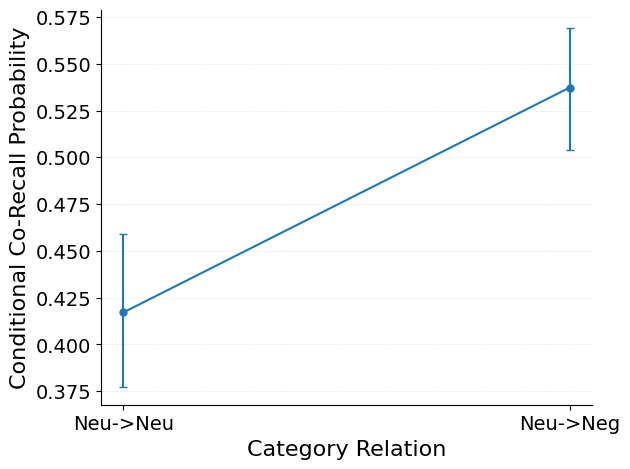

In [5]:
#| code-summary: Plot conditional co-recall by category
#| label: fig-conditional-corec-by-cat
#| fig-cap: "Conditional co-recall probability grouped by category relation."
plot_conditional_corec_by_cat(
    data,
    trial_mask,
    category_field=category_field,
    category_value=category_value,
    relation_labels=relation_labels,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

Each dataset is paired with its corresponding mask by index. To compare conditions within one dataset, pass the dataset multiple times with different masks: `plot_conditional_corec_by_cat([data, data], [mask_a, mask_b], ...)`.

In [6]:
#| echo: false
show_doc(plot_conditional_corec_by_cat)

---

### plot_conditional_corec_by_cat

>      plot_conditional_corec_by_cat (datasets:Union[Sequence[jaxcmr.typing.Reca
>                                     llDataset],jaxcmr.typing.RecallDataset], t
>                                     rial_masks:Union[Sequence[jaxtyping.Bool[A
>                                     rray,'trial_count']],jaxtyping.Bool[Array,
>                                     'trial_count']], category_field:str,
>                                     category_value:int,
>                                     relation_labels:Sequence[str]=('Same',
>                                     'Different'),
>                                     color_cycle:Optional[list[str]]=None,
>                                     labels:Optional[Sequence[str]]=None,
>                                     contrast_name:Optional[str]=None, axis:Opt
>                                     ional[matplotlib.axes._axes.Axes]=None,
>                                     confidence_level:float=0.95)

*Plot conditional co-recall by category with confidence intervals.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Dataset or list of datasets to plot. |
| trial_masks | Union |  | Boolean masks selecting trials within each<br>dataset. |
| category_field | str |  | Dataset key containing per-study-item<br>categories. |
| category_value | int |  | Reference category defining the anchors. |
| relation_labels | Sequence | ('Same', 'Different') | Tick labels for same- and different-category<br>neighbor probabilities. |
| color_cycle | Optional | None | Colors for plotting each dataset. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title for contrasts. |
| axis | Optional | None | Existing Matplotlib ``Axes`` to plot on. |
| confidence_level | float | 0.95 | Confidence level for the bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with conditional co-recall<br>by category curves.** |

The `plot_conditional_corec_by_cat` function uses `conditional_corec_by_cat` internally, which aggregates trial-level category-conditioned co-recall counts across the dataset.

In [7]:
#| echo: false
show_doc(conditional_corec_by_cat)

---

### conditional_corec_by_cat

>      conditional_corec_by_cat (dataset:jaxcmr.typing.RecallDataset,
>                                category_field:str, category_value:int)

*Return conditional category-wise co-recall probabilities.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Recall dataset containing ``recalls`` and<br>the requested category field. |
| category_field | str | Key mapping to per-trial study-item<br>categories. |
| category_value | int | Reference category defining the anchor items. |
| **Returns** | **Float[Array, 'relation']** | **Same- and different-category conditional<br>co-recall probabilities.** |

In [8]:
# Two same-category items recalled: same-cat probability is 1.0
recalls = jnp.array([[1, 2, 0]], dtype=jnp.int32)
categories = jnp.array([[1, 1, 2]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 3, dtype=jnp.int32),
    "pres_itemnos": jnp.array([[1, 2, 3]], dtype=jnp.int32),
    "recalls": recalls,
    "cat": categories,
}

result = conditional_corec_by_cat(dataset, "cat", 1)
assert float(result[0]) == 1.0